In [4]:
import os

os.makedirs("data", exist_ok=True)
os.makedirs("plots", exist_ok=True)

Anomaly detected at index 20, value=100.0
Anomaly detected at index 31, value=59.26139092254469
Anomaly detected at index 70, value=10.0
Anomaly detected at index 74, value=36.901274479551276
Anomaly detected at index 79, value=40.06215542699554


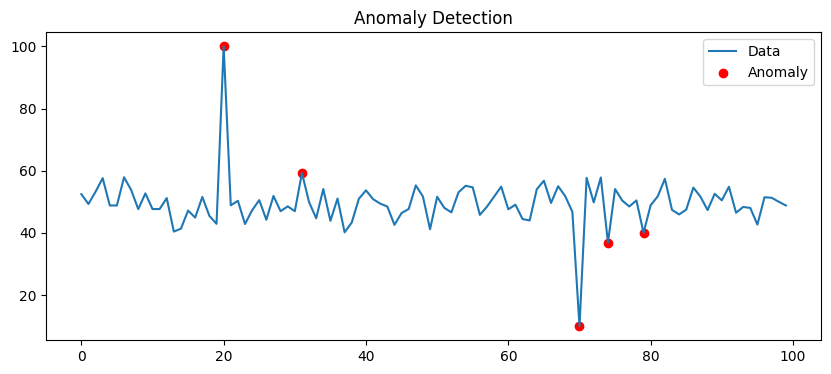

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
import smtplib
import requests
import os

# ---------- Alert Functions ----------
def send_email_alert(subject, body, to_email):
    from_email = "your_email@example.com"
    password = "your_password"  # use env vars in practice
    msg = f"Subject: {subject}\n\n{body}"
    with smtplib.SMTP("smtp.gmail.com", 587) as server:
        server.starttls()
        server.login(from_email, password)
        server.sendmail(from_email, to_email, msg)

def send_slack_alert(message, webhook_url):
    payload = {"text": message}
    requests.post(webhook_url, json=payload)

# ---------- Main Pipeline ----------
def main():
    os.makedirs("data", exist_ok=True)
    os.makedirs("plots", exist_ok=True)

    # Step 1: Simulate data
    np.random.seed(42)
    data = np.random.normal(50, 5, 100)
    data[20] = 100   # spike
    data[70] = 10    # drop
    df = pd.DataFrame({'value': data})
    df.to_csv("data/01_raw_data.csv", index=False)

    # Step 2: Detect anomalies
    model = IsolationForest(contamination=0.05, random_state=42)
    df['anomaly'] = model.fit_predict(df[['value']])
    df.to_csv("data/02_detection_results.csv", index=False)

    anomalies = df[df['anomaly'] == -1]
    anomalies.to_csv("data/03_anomalies.csv", index=False)

    # Step 3: Save plot
    plt.figure(figsize=(10,4))
    plt.plot(df['value'], label='Data')
    plt.scatter(anomalies.index, anomalies['value'], color='red', label='Anomaly')
    plt.legend()
    plt.title("Anomaly Detection")
    plt.savefig("plots/04_anomaly_plot.png")

    # Step 4: Save alert log
    with open("data/05_alert_log.txt", "w") as f:
        for idx, row in anomalies.iterrows():
            alert_msg = f"Anomaly detected at index {idx}, value={row['value']}"
            f.write(alert_msg + "\n")
            print(alert_msg)
            # Uncomment to send alerts:
            # send_email_alert("Anomaly Alert", alert_msg, "recipient@example.com")
            # send_slack_alert(alert_msg, "https://hooks.slack.com/services/XXXX/XXXX/XXXX")

if __name__ == "__main__":
    main()

In [6]:
print("Data folder contents:", os.listdir("data"))
print("Plots folder contents:", os.listdir("plots"))

Data folder contents: ['01_raw_data.csv', '02_detection_results.csv', '03_anomalies.csv', '05_alert_log.txt']
Plots folder contents: ['04_anomaly_plot.png']


In [7]:
import pandas as pd

print("Raw Data:")
print(pd.read_csv("data/01_raw_data.csv").head())

print("\nDetection Results:")
print(pd.read_csv("data/02_detection_results.csv").head())

print("\nAnomalies Only:")
print(pd.read_csv("data/03_anomalies.csv").head())

Raw Data:
       value
0  52.483571
1  49.308678
2  53.238443
3  57.615149
4  48.829233

Detection Results:
       value  anomaly
0  52.483571        1
1  49.308678        1
2  53.238443        1
3  57.615149        1
4  48.829233        1

Anomalies Only:
        value  anomaly
0  100.000000       -1
1   59.261391       -1
2   10.000000       -1
3   36.901274       -1
4   40.062155       -1


In [8]:
from PIL import Image
Image.open("plots/04_anomaly_plot.png").show()

In [9]:
with open("data/05_alert_log.txt") as f:
    print(f.read())

Anomaly detected at index 20, value=100.0
Anomaly detected at index 31, value=59.26139092254469
Anomaly detected at index 70, value=10.0
Anomaly detected at index 74, value=36.901274479551276
Anomaly detected at index 79, value=40.06215542699554

